# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [10]:
# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, scipy.stats, and sklearn modules
# Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# From scipy import stats
# From sklearn.model_selection import train_test_split
# From sklearn.linear_model import LinearRegression
# From sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# From sklearn.preprocessing import StandardScaler

# Your code here:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")

In [30]:
# TODO: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('airtraffic.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (249, 17)


## 2. Exploratory Data Analysis

In [31]:
# TODO: Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
df.info()

print("\nFirst 5 rows:")
print(df.head())

print("\nBasic Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     249 non-null    int64  
 1   Month    249 non-null    int64  
 2   Dom_Pax  249 non-null    object 
 3   Int_Pax  249 non-null    object 
 4   Pax      249 non-null    object 
 5   Dom_Flt  249 non-null    object 
 6   Int_Flt  249 non-null    object 
 7   Flt      249 non-null    object 
 8   Dom_RPM  249 non-null    object 
 9   Int_RPM  249 non-null    object 
 10  RPM      249 non-null    object 
 11  Dom_ASM  249 non-null    object 
 12  Int_ASM  249 non-null    object 
 13  ASM      249 non-null    object 
 14  Dom_LF   249 non-null    float64
 15  Int_LF   249 non-null    float64
 16  LF       249 non-null    float64
dtypes: float64(3), int64(2), object(12)
memory usage: 33.2+ KB

First 5 rows:
   Year  Month     Dom_Pax    Int_Pax         Pax  Dom_Flt Int_Flt      Flt  \
0

In [32]:
object_cols = df.select_dtypes(include='object').columns

for col in object_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     249 non-null    int64  
 1   Month    249 non-null    int64  
 2   Dom_Pax  249 non-null    int64  
 3   Int_Pax  249 non-null    int64  
 4   Pax      249 non-null    int64  
 5   Dom_Flt  249 non-null    int64  
 6   Int_Flt  249 non-null    int64  
 7   Flt      249 non-null    int64  
 8   Dom_RPM  249 non-null    int64  
 9   Int_RPM  249 non-null    int64  
 10  RPM      249 non-null    int64  
 11  Dom_ASM  249 non-null    int64  
 12  Int_ASM  249 non-null    int64  
 13  ASM      249 non-null    int64  
 14  Dom_LF   249 non-null    float64
 15  Int_LF   249 non-null    float64
 16  LF       249 non-null    float64
dtypes: float64(3), int64(14)
memory usage: 33.2 KB


In [33]:
print(df.columns)
df.head()

Index(['Year', 'Month', 'Dom_Pax', 'Int_Pax', 'Pax', 'Dom_Flt', 'Int_Flt',
       'Flt', 'Dom_RPM', 'Int_RPM', 'RPM', 'Dom_ASM', 'Int_ASM', 'ASM',
       'Dom_LF', 'Int_LF', 'LF'],
      dtype='object')


,Year,Month,Dom_Pax,Int_Pax,Pax,Dom_Flt,Int_Flt,Flt,Dom_RPM,Int_RPM,RPM,Dom_ASM,Int_ASM,ASM,Dom_LF,Int_LF,LF
0,2003,1,43032450,4905830,47938280,785160,57667,842827,36211422,12885980,49097402,56191300,17968572,74159872,64.44,71.71,66.20
1,2003,2,41166780,4245366,45412146,690351,51259,741610,34148439,10715468,44863907,50088434,15587880,65676314,68.18,68.74,68.31
2,2003,3,49992700,5008613,55001313,797194,58926,856120,41774564,12567068,54341633,57592901,17753174,75346075,72.53,70.79,72.12
3,2003,4,47033260,4345444,51378704,766260,55005,821265,39465980,10370592,49836572,54639679,15528761,70168440,72.23,66.78,71.02
4,2003,5,49152352,4610834,53763186,789397,55265,844662,41001934,11575026,52576960,55349897,15629821,70979718,74.08,74.06,74.07


In [34]:
# TODO: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
print(df.isnull().sum())

# Handle missing values if any
# if df.isnull().sum().sum() > 0:
#     print("\nHandling missing values...")
#     df = df.dropna()
#     print(f"New shape after handling missing values: {df.shape}")
# else:
#     print("\nNo missing values found.")

Missing values:
Year       0
Month      0
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_RPM    0
Int_RPM    0
RPM        0
Dom_ASM    0
Int_ASM    0
ASM        0
Dom_LF     0
Int_LF     0
LF         0
dtype: int64


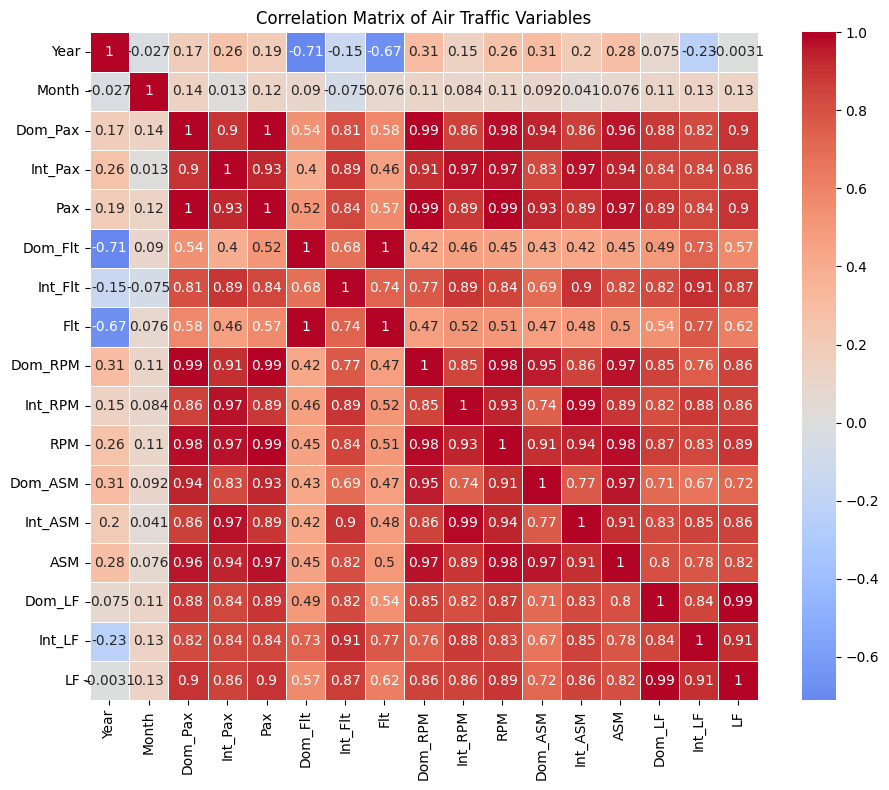

Strongest correlations:
Dom_Pax  Pax        0.997455
Pax      Dom_Pax    0.997455
Flt      Dom_Flt    0.997068
Dom_Flt  Flt        0.997068
LF       Dom_LF     0.989608
Dom_LF   LF         0.989608
Pax      Dom_RPM    0.989246
Dom_RPM  Pax        0.989246
Pax      RPM        0.988162
RPM      Pax        0.988162
dtype: float64


In [35]:
# TODO: Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(10, 8))

# Calculate correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Create heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

print("Strongest correlations:")

# Exclude diagonal correlations of 1.0
corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1].sort_values(ascending=False)

print(corr_pairs.head(10))


## 3. Hypothesis Testing

In [36]:
# TODO: Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

alpha = 0.05

if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("There is a statistically significant difference between the mean domestic passengers and mean international passengers.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is not enough evidence to say that the mean domestic passengers and mean international passengers are different.")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 70.9547
P-value: 0.000000
Mean Domestic Passengers: 55209710
Mean International Passengers: 7392209

Conclusion: Reject H0 (p < 0.05)
There is a statistically significant difference between the mean domestic passengers and mean international passengers.


In [37]:
# TODO: Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# Interpret the correlation test results
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("There is a significant correlation between total passengers and total flights.")

    if correlation_coef > 0:
        print("The correlation is positive, meaning that as the number of flights increases, the number of passengers also tends to increase.")
    else:
        print("The correlation is negative, meaning that as the number of flights increases, the number of passengers tends to decrease.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is not enough evidence to conclude that there is a correlation between total passengers and total flights.")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.5698
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
The correlation is positive, meaning that as the number of flights increases, the number of passengers also tends to increase.


## 4. Simple Linear Regression

In [38]:
# TODO: Build a simple linear regression model
# Goal: Predict Total Passengers from Total Flights
# Hint: Use sklearn's LinearRegression class
print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data
X_simple = df[['Flt']]      # Feature must be 2D
y_simple = df['Pax']        # Target

# Split the data
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple,
    y_simple,
    test_size=0.2,
    random_state=42
)

# Create and train the model
simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train_simple)

# Make predictions
y_pred_simple = simple_model.predict(X_test_simple)

# Calculate performance metrics
r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

print(
    f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} "
    f"+ {simple_model.coef_[0]:.2f} × Flights"
)

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: -0.0092
Mean Squared Error: 110855922051702.88
Root Mean Squared Error: 10528813.90
Mean Absolute Error: 9262992.73

Model Equation: Passengers = 13253573.91 + 63.71 × Flights


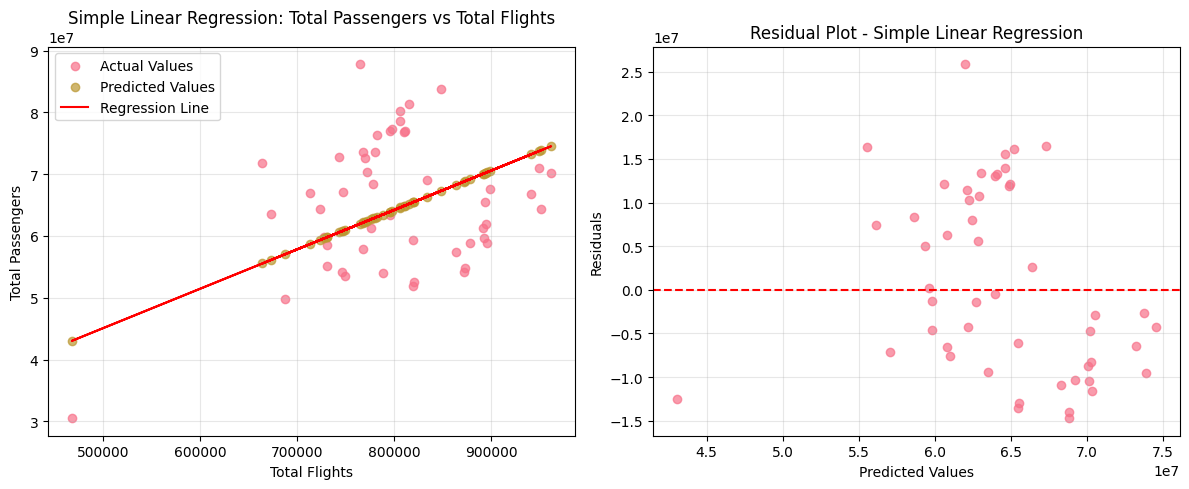

In [39]:
# TODO: Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

# Plot 1: Scatter plot with regression line
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.scatter(X_test_simple, y_test_simple, label='Actual Values', alpha=0.7)
plt.scatter(X_test_simple, y_pred_simple, label='Predicted Values', alpha=0.7)

# Regression line
plt.plot(X_test_simple, y_pred_simple, color='red', label='Regression Line')

plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)


# Plot 2: Residual plot
plt.subplot(1, 2, 2)

residuals = y_test_simple - y_pred_simple

plt.scatter(y_pred_simple, residuals, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [40]:
# TODO: Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Hint: Avoid using Pax in features since that's our target (multicollinearity)
print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# Select features
feature_columns = ['Dom_Flt', 'Int_Flt', 'Dom_RPM', 'Int_RPM', 'Dom_LF', 'Int_LF']

X_multiple = df[feature_columns]
y_multiple = df['Pax']

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# Split the data
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(
    X_multiple,
    y_multiple,
    test_size=0.2,
    random_state=42
)

# Apply feature scaling
scaler = StandardScaler()
X_train_mult_scaled = scaler.fit_transform(X_train_mult)
X_test_mult_scaled = scaler.transform(X_test_mult)

# Create and train the model
multiple_model = LinearRegression()
multiple_model.fit(X_train_mult_scaled, y_train_mult)

# Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled)

# Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult)
mse_mult = mean_squared_error(y_test_mult, y_pred_mult)
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_mult = np.sqrt(mse_mult)

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")

print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Flt', 'Int_Flt', 'Dom_RPM', 'Int_RPM', 'Dom_LF', 'Int_LF']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 0.9971
Mean Squared Error: 320532001178.00
Root Mean Squared Error: 566155.46
Mean Absolute Error: 449167.92

Feature Coefficients (after scaling):
Dom_Flt: 1166976.2104
Int_Flt: -134396.0574
Dom_RPM: 9930011.6905
Int_RPM: 1242323.3141
Dom_LF: 749183.1080
Int_LF: 497416.2139
Intercept: 61921705.70


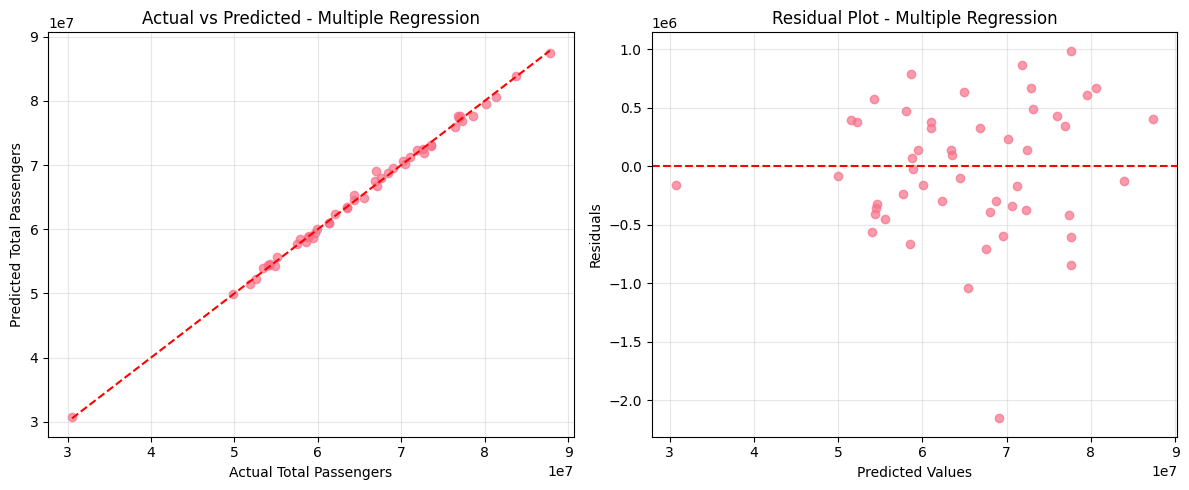

In [41]:
# TODO: Visualize multiple regression results
# Create actual vs predicted plot and residual plot
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)

plt.scatter(y_test_mult, y_pred_mult, alpha=0.7)

# Perfect prediction line
min_val = min(y_test_mult.min(), y_pred_mult.min())
max_val = max(y_test_mult.max(), y_pred_mult.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.grid(True, alpha=0.3)


# Plot 2: Residual plot
plt.subplot(1, 2, 2)

residuals_mult = y_test_mult - y_pred_mult

plt.scatter(y_pred_mult, residuals_mult, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [42]:
# TODO: Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

# TODO: Print comparison of R², RMSE, and MAE
# Hint: Use the metrics calculated in previous sections

print(f"{'R² Score':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'RMSE':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'MAE':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")

print("=" * 50)

# TODO: Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = ((r2_mult - r2_simple) / abs(r2_simple)) * 100
else:
    better_model = "Simple Regression"
    improvement = ((r2_simple - r2_mult) / abs(r2_mult)) * 100

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score                  -0.0092              0.9971              
RMSE                      10528813.90          566155.46           
MAE                       9262992.73           449167.92           

Best Model: Multiple Regression
R² Improvement: 10892.02%


## 7. Statistical Insights and Conclusions

In [43]:
print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
print("   • Domestic vs International Passengers: Reject H0. There is a statistically significant difference between domestic and international passengers.")
print("   • Correlation between Total Passengers and Flights: Reject H0. There is a statistically significant positive correlation between total passengers and total flights.")

print("\n2. REGRESSION ANALYSIS:")
print(f"   • Simple Linear Regression R²: {r2_simple:.4f}. This model performs poorly and does not explain passenger variation well.")
print(f"   • Multiple Linear Regression R²: {r2_mult:.4f}. This model performs very well and explains most of the variation in total passengers.")
print(f"   • Best performing model: {better_model}")

print("\n3. KEY FINDINGS:")
print("   • Domestic passenger traffic is much higher than international passenger traffic.")
print("   • Total passengers and total flights have a moderate positive relationship.")
print("   • Multiple features such as flights, RPM, and load factor predict passengers much better than flights alone.")

print("\n4. RECOMMENDATIONS:")
print("   • Use multiple regression instead of simple regression for better passenger prediction.")
print("   • Include traffic-related features such as RPM, flights, and load factor in future models.")
print("   • Avoid using derived target-related columns that cause data leakage, such as using Pax to predict Pax.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: Reject H0. There is a statistically significant difference between domestic and international passengers.
   • Correlation between Total Passengers and Flights: Reject H0. There is a statistically significant positive correlation between total passengers and total flights.

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: -0.0092. This model performs poorly and does not explain passenger variation well.
   • Multiple Linear Regression R²: 0.9971. This model performs very well and explains most of the variation in total passengers.
   • Best performing model: Multiple Regression

3. KEY FINDINGS:
   • Domestic passenger traffic is much higher than international passenger traffic.
   • Total passengers and total flights have a moderate positive relationship.
   • Multiple features such as flights, RPM, and load factor predict passengers much better than flights alone.


## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

  The tests showed that domestic and international passenger averages are significantly different. Also, total passengers and total flights have a significant positive correlation. These results were expected.

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   The multiple regression model performed better because it used more useful features. The R² value shows how much variation in passengers the model can explain.

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   The strongest correlations were between Pax and Dom_Pax, Flt and Dom_Flt, and LF and Dom_LF. Airlines can use these relationships to understand what drives total traffic.

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

  The simple model had larger errors and weaker performance. The multiple regression residuals were smaller, showing better predictions.

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

   Airlines can use these models to forecast passenger demand, plan flights, manage capacity, and improve operational decisions.